# 01 — Data EDA (guide §5)

**Rerun on every dataset version.** Panels: label counts and stratification
cells, sampling strategy, reliability, text lengths vs encoder budgets,
conversational-context coverage, temporal coverage (viability check),
agreement echo, manual read of sarcastic rows, readiness gate, frozen folds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from leische import data as D
from leische.nbsupport import bootstrap

cfg, df, corpus, card, gate = bootstrap(need_corpus=True)
SMOKE = cfg.tag()  # prefix for every printed number below

 SMOKE MODE — every number in this notebook is a harness or
 architecture check on the pilot export, NOT a reportable result.
dataset identity: {'dataset_version': 'v1', 'prompt_version': 'sarc-v1', 'uyam_commit': '69d0affaca157edaf64e617d21e8ae752c9343fa'}
rows: 100  sarcastic: 8  corpus: loaded

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [FAIL] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.


## Label counts and stratification cells

Any `language × sarcastic` cell < 10 is flagged — those cells make 5-fold
stratification meaningless (§10 gate criterion).

In [2]:
sarc = D.sarcastic(df)
lang = D.language(df)
print(f"{SMOKE}sarcastic: {sarc.sum()} / {len(df)} ({sarc.mean():.1%})")
cells = pd.crosstab(lang, sarc)
print(f"\n{SMOKE}language × sarcastic cells:")
print(cells)
thin = [(l, s, int(cells.loc[l, s])) for l in cells.index for s in cells.columns
        if cells.loc[l, s] < 10]
for l, s, n in thin:
    print(f"  FLAG: cell ({l}, sarcastic={s}) has only {n} rows (<10)")
print(f"\n{SMOKE}{len(thin)} thin cell(s) — the pilot cannot support stratified 5-fold "
      "training; this is exactly why the §10 gate fails.")

SMOKE sarcastic: 8 / 100 (8.0%)

SMOKE language × sarcastic cells:
labels   False  True 
labels               
english     26      2
tagalog     16      1
taglish     50      5
  FLAG: cell (english, sarcastic=True) has only 2 rows (<10)
  FLAG: cell (tagalog, sarcastic=True) has only 1 rows (<10)
  FLAG: cell (taglish, sarcastic=True) has only 5 rows (<10)

SMOKE 3 thin cell(s) — the pilot cannot support stratified 5-fold training; this is exactly why the §10 gate fails.


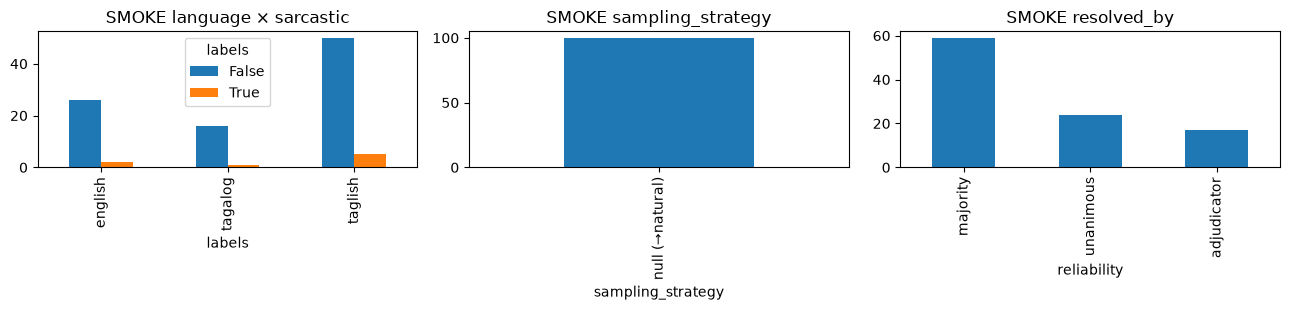

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
cells.plot.bar(ax=axes[0], title=f"{SMOKE}language × sarcastic")
df["sampling_strategy"].fillna("null (→natural)").value_counts().plot.bar(
    ax=axes[1], title=f"{SMOKE}sampling_strategy")
df["reliability"].map(lambda r: r["resolved_by"]).value_counts().plot.bar(
    ax=axes[2], title=f"{SMOKE}resolved_by")
plt.tight_layout()
plt.show()

## Reliability: vote patterns × resolution path

In [4]:
rel = pd.DataFrame({
    "resolved_by": df["reliability"].map(lambda r: r["resolved_by"]),
    "sarcasm_votes": df["reliability"].map(lambda r: r["sarcasm_votes"]),
    "mean_confidence": df["reliability"].map(lambda r: r["mean_confidence"]),
})
print(f"{SMOKE}votes × resolution:")
print(pd.crosstab(rel["sarcasm_votes"], rel["resolved_by"]))
print(f"\n{SMOKE}mean self-reported confidence: {rel['mean_confidence'].mean():.3f} "
      "(weakly calibrated — vote pattern is the trusted signal, contract §8)")

SMOKE votes × resolution:
resolved_by    adjudicator  majority  unanimous
sarcasm_votes                                  
2-1                     17         0          0
3-0                      0        59         24

SMOKE mean self-reported confidence: 0.926 (weakly calibrated — vote pattern is the trusted signal, contract §8)


## Text lengths vs the Stage-1 truncation budgets

Budgets (guide §4.1): target 192, context items 96, selftext 128 tokens.

C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gio\.cache\huggingface\hub\models--xlm-roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


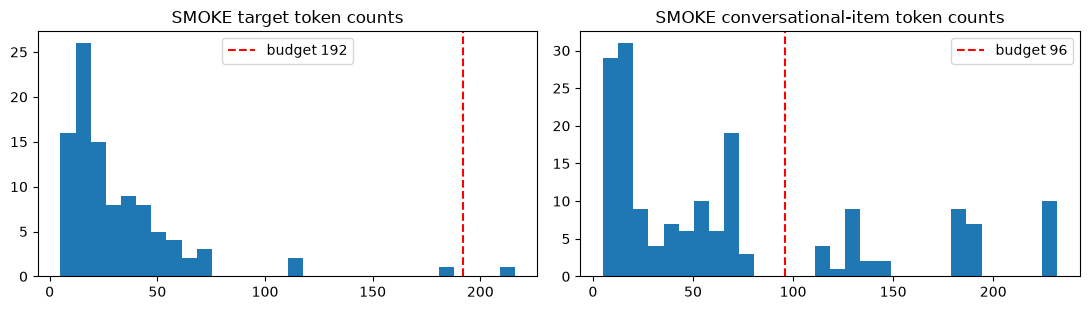

SMOKE targets over budget: 1.0% | context items over budget: 26.2%
note: corpus text carries mojibake (e.g. â€™ for ’) from collection-time encoding; labels were conditioned on the text AS-IS, so we never 'fix' it (§11.7).


In [5]:
from leische.contexts import build_conversational
from leische.encoders import Tokenize

tok = Tokenize(cfg.encoder_name, cfg.max_len_target, cfg.max_len_context, cfg.max_len_selftext)
target_tokens = df["text"].map(tok.token_count)
ctx_tokens = [tok.token_count(it.text) for _, r in df.iterrows()
              for it in build_conversational(r)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(target_tokens, bins=30)
axes[0].axvline(cfg.max_len_target, color="r", ls="--", label=f"budget {cfg.max_len_target}")
axes[0].set_title(f"{SMOKE}target token counts"); axes[0].legend()
axes[1].hist(ctx_tokens, bins=30)
axes[1].axvline(cfg.max_len_context, color="r", ls="--", label=f"budget {cfg.max_len_context}")
axes[1].set_title(f"{SMOKE}conversational-item token counts"); axes[1].legend()
plt.tight_layout(); plt.show()

over_t = (target_tokens > cfg.max_len_target).mean()
over_c = np.mean([c > cfg.max_len_context for c in ctx_tokens]) if ctx_tokens else 0.0
print(f"{SMOKE}targets over budget: {over_t:.1%} | context items over budget: {over_c:.1%}")
print("note: corpus text carries mojibake (e.g. â€™ for ’) from collection-time "
      "encoding; labels were conditioned on the text AS-IS, so we never 'fix' it (§11.7).")

## Conversational-context coverage

In [6]:
conv_stats = pd.DataFrame([
    {
        "has_submission": r["context"]["submission"] is not None,
        "n_parents": len(r["context"]["parent_chain"] or []),
        "n_replies": len(r["context"]["replies"] or []),
    }
    for _, r in df.iterrows()
])
print(f"{SMOKE}% with submission snapshot: {conv_stats['has_submission'].mean():.1%}")
print(f"{SMOKE}% with ≥1 parent: {(conv_stats['n_parents'] > 0).mean():.1%} "
      f"(mean chain length {conv_stats['n_parents'].mean():.2f})")
print(f"{SMOKE}% with ≥1 reply: {(conv_stats['n_replies'] > 0).mean():.1%} "
      f"(mean {conv_stats['n_replies'].mean():.2f})")

SMOKE % with submission snapshot: 100.0%
SMOKE % with ≥1 parent: 28.0% (mean chain length 0.34)
SMOKE % with ≥1 reply: 31.0% (mean 0.34)


## Temporal coverage — is author-history context viable at all?

Prior-post counts per dataset row, reconstructed from `corpus-v1.jsonl`
by `author_hash` (strictly-before rule). Guide §5 calls this the panel that
"decides whether temporal context is viable".

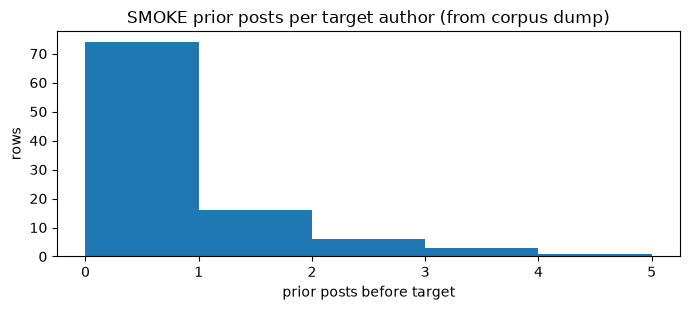

SMOKE rows with ≥1 prior posts: 26.0%
SMOKE rows with ≥3 prior posts: 4.0%
SMOKE rows with ≥10 prior posts: 0.0%
SMOKE median prior posts: 0 — rows without history get the zeros/'missing' channel and the Stage-4 gate learns to suppress it (§4.2).


In [7]:
from leische.contexts import TemporalIndex

tindex = TemporalIndex(corpus)
prior_counts = tindex.prior_counts(df)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(prior_counts, bins=range(0, int(prior_counts.max()) + 2))
ax.set_title(f"{SMOKE}prior posts per target author (from corpus dump)")
ax.set_xlabel("prior posts before target"); ax.set_ylabel("rows")
plt.tight_layout(); plt.show()

for k in (1, 3, cfg.temporal_k):
    print(f"{SMOKE}rows with ≥{k} prior posts: {(prior_counts >= k).mean():.1%}")
print(f"{SMOKE}median prior posts: {prior_counts.median():.0f} — rows without history "
      "get the zeros/'missing' channel and the Stage-4 gate learns to suppress it (§4.2).")

## Agreement statistics (echoed from dataset_card.json)

These are the dataset's reliability evidence — cite them, don't recompute.

In [8]:
ag = card["agreement"]["labels"]
print(pd.DataFrame({
    label: {"fleiss_kappa": v["fleiss_kappa"], "krippendorff_alpha": v["krippendorff_alpha"]}
    for label, v in ag.items()
}).T)
gold = card["agreement"]["gold_vs_ensemble_cohen_kappa"]
print(f"\ngold subset: n={gold['n_gold_items']} → human-vs-ensemble κ not yet available "
      "(gate criterion #3)")
print(f"fastText-LID vs ensemble language agreement: {card['agreement']['lid_vs_ensemble_language']['agreement']:.2f}")

                    fleiss_kappa  krippendorff_alpha
sarcastic                 0.5556              0.5570
language                  0.3960              0.3981
literal_sentiment         0.6692              0.6703
intended_sentiment        0.7048              0.7058

gold subset: n=0 → human-vs-ensemble κ not yet available (gate criterion #3)
fastText-LID vs ensemble language agreement: 0.72


## Manual read: every sarcastic row with all three annotator rationales

Guide §5 asks for a 20-row read; the pilot has only 8 sarcastic rows, so all
of them are shown (SMOKE).

In [9]:
for _, r in df[sarc].iterrows():
    labels = r["labels"]
    print("=" * 100)
    print(f"[{r['reddit_fullname']}] lang={labels['language']} "
          f"literal={labels['literal_sentiment']} intended={labels['intended_sentiment']} "
          f"votes={r['reliability']['sarcasm_votes']} resolved={r['reliability']['resolved_by']}")
    print(f"TEXT: {r['text'][:300]}")
    cues = [k for k, v in labels["cues"].items() if v]
    print(f"CUES: {', '.join(cues) or '—'}")
    for a in r["reliability"]["annotators"]:
        print(f"  {a['model_key']:<8} sarcastic={a['sarcastic']} conf={a['confidence']:.2f} | {a['rationale']}")

[t1_p12zfuz] lang=taglish literal=neutral intended=negative votes=3-0 resolved=majority
TEXT: di naman siguro sobrang selan ng guests mo, hehe pero better serve mo pag lasing na sila 
CUES: polarity_inversion, rhetorical_intent
  gemma3   sarcastic=True conf=0.85 | The comment implies the tequila is bad enough to only serve when guests are already drunk, using 'hehe' as a softening device for the criticism.
  qwen3    sarcastic=True conf=0.90 | The comment mocks the idea of serving El Hombre tequila by implying it's only suitable when guests are drunk, using 'hehe' to signal sarcasm.
  sealion  sarcastic=True conf=0.85 | Suggests the tequila is not good, implying guests won't mind its quality only when drunk, hence sarcastic.
[t1_p130vn2] lang=taglish literal=negative intended=negative votes=3-0 resolved=majority
TEXT: Kahit gano kamahal, pareho lang na isusuka at ikakasakit ng ulo
CUES: polarity_inversion, contextual_incongruity
  gemma3   sarcastic=True conf=0.85 | The comment implie

## Freeze the fold assignment for this dataset version (§7.1)

`StratifiedGroupKFold(5)` on `sarcastic×language`, grouped by
`submission_fullname`, val carved from the train side with the same grouping.
Saved once to `results/folds-v1.json`; every experiment reuses it.

In [10]:
import warnings

if cfg.folds_file().exists():
    folds = D.load_folds(cfg.folds_file(), card)
    print(f"frozen folds already exist and match this export: {cfg.folds_file()}")
else:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        folds = D.make_folds(df, n_splits=cfg.n_folds, seed=13, smoke=True)
    for w in caught:
        print(f"WARNING: {w.message}")
    D.freeze_folds(folds, card, cfg.folds_file(), n_splits=cfg.n_folds, seed=13)
    print(f"froze {len(folds)} folds → {cfg.folds_file()}")

fold_pos = [
    {"fold": f["fold"],
     **{p: f"{len(f[p])} rows / "
           f"{int(sarc[df['reddit_fullname'].isin(f[p])].sum())} pos" for p in ("train", "val", "test")}}
    for f in folds
]
print(f"\n{SMOKE}fold composition (rows / sarcastic positives):")
print(pd.DataFrame(fold_pos).to_string(index=False))

froze 5 folds → C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json

SMOKE fold composition (rows / sarcastic positives):
 fold           train             val            test
    0 77 rows / 8 pos  3 rows / 0 pos 20 rows / 0 pos
    1 77 rows / 6 pos  3 rows / 0 pos 20 rows / 2 pos
    2 70 rows / 7 pos 10 rows / 0 pos 20 rows / 1 pos
    3 61 rows / 5 pos 18 rows / 0 pos 21 rows / 3 pos
    4 69 rows / 4 pos 12 rows / 2 pos 19 rows / 2 pos


In [11]:
rep = D.author_overlap_report(df, folds)
print(f"{SMOKE}author overlap audit (§7.1):")
print(rep.to_string(index=False))
print(f"authors appearing in >1 test fold: {rep.attrs['authors_in_multiple_test_folds']} "
      f"/ {rep.attrs['total_test_authors']} — if a few authors dominate later exports, "
      "add author_hash to the grouping key as a robustness run.")

SMOKE author overlap audit (§7.1):
 fold  n_test_rows  n_test_authors
    0           20              17
    1           20              16
    2           20              17
    3           21              20
    4           19              17
authors appearing in >1 test fold: 3 / 84 — if a few authors dominate later exports, add author_hash to the grouping key as a robustness run.


## Readiness gate verdict

In [12]:
print(gate.render())

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [FAIL] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.
